# Term Deposit Subscription Prediction (Bank Marketing)


---

## Problem Statement and Objective

**Objective:** Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.

**Business Context:**
Portuguese banking institutions conducted marketing campaigns based on phone calls. Often, more than one contact to the same client was required to assess if the product (bank term deposit) would be subscribed. The goal is to build a classification model that can predict whether a client will subscribe to a term deposit, enabling the bank to optimize their marketing efforts and focus on high-probability customers.

**Skills Demonstrated:**
- Classification modeling
- Feature encoding
- Model interpretability (Explainable AI - XAI)
- Customer behavior analysis

## 1. Import Required Libraries

In [1]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                           f1_score, roc_auc_score, roc_curve, 
                           accuracy_score, precision_score, recall_score)

# Explainable AI libraries
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Dataset Description and Loading

**Dataset:** Bank Marketing Dataset (UCI Machine Learning Repository)

**Features:**
- `age`: Client age
- `job`: Type of job
- `marital`: Marital status
- `education`: Education level
- `default`: Has credit in default?
- `balance`: Average yearly balance in euros
- `housing`: Has housing loan?
- `loan`: Has personal loan?
- `contact`: Contact communication type
- `day`: Last contact day of the month
- `month`: Last contact month of year
- `duration`: Last contact duration in seconds
- `campaign`: Number of contacts performed during this campaign
- `pdays`: Number of days since last contacted
- `previous`: Number of contacts performed before this campaign
- `poutcome`: Outcome of the previous marketing campaign
- `y`: Target variable - Has the client subscribed to a term deposit?

In [2]:
# Load the Bank Marketing dataset from local Kaggle input path
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/fahadullah1508/bank-full/bank-full.csv', sep=';')

# Display basic information
print('Dataset Shape:', df.shape)
print('First 5 rows:')
display(df.head())

Dataset Shape: (45211, 17)
First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# Dataset info and statistics
print('Dataset Info:')
print('=' * 50)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
# Statistical summary of numerical features
print('Statistical Summary of Numerical Features:')
print('=' * 60)
display(df.describe())

Statistical Summary of Numerical Features:


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [5]:
# Check for missing values
print('Missing Values Check:')
print('=' * 40)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')

# Check for 'unknown' values which are essentially missing
print("'Unknown' values in categorical columns:")
for col in df.select_dtypes(include=['object']).columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"  {col}: {unknown_count} ({unknown_count/len(df)*100:.2f}%)")

Missing Values Check:
No missing values found!
'Unknown' values in categorical columns:
  job: 288 (0.64%)
  education: 1857 (4.11%)
  contact: 13020 (28.80%)
  poutcome: 36959 (81.75%)


## 3. Exploratory Data Analysis (EDA)

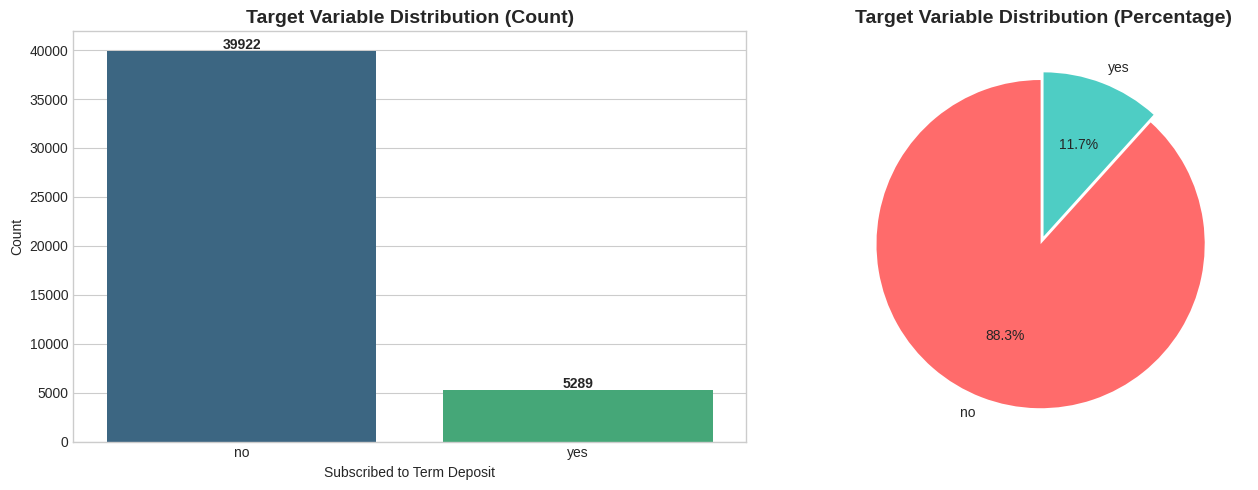

In [6]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='y', ax=axes[0], palette='viridis')
axes[0].set_title('Target Variable Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subscribed to Term Deposit')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['y'].value_counts().values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
df['y'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], 
                                colors=['#FF6B6B', '#4ECDC4'], 
                                startangle=90, explode=(0.05, 0))
axes[1].set_title('Target Variable Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

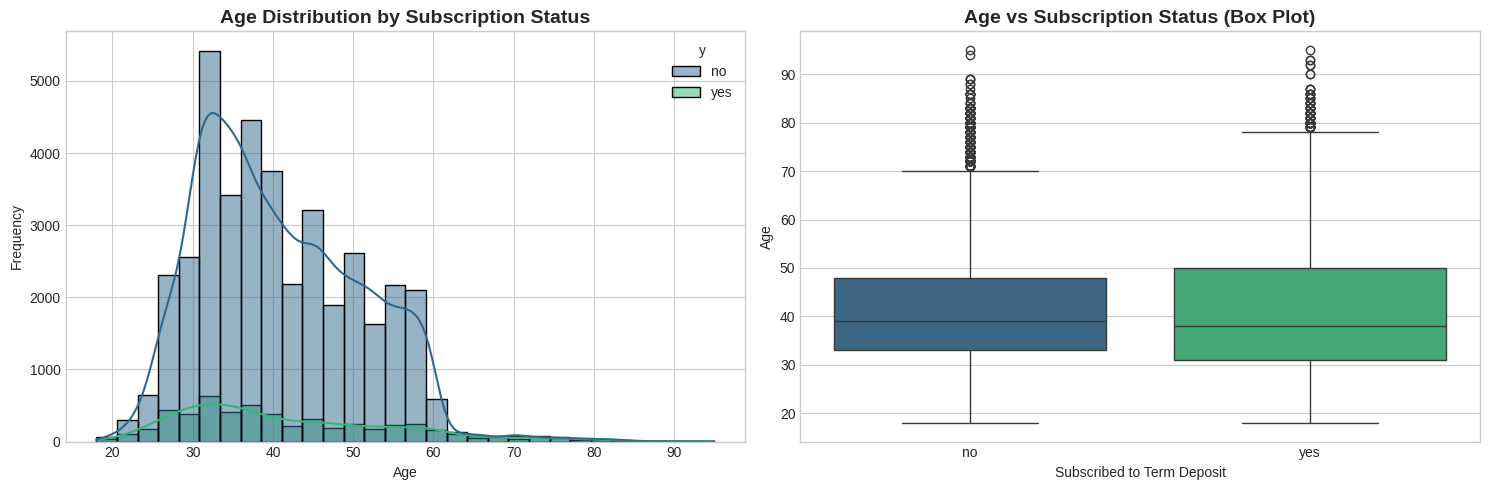

In [7]:
# Age distribution by target
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Age distribution
sns.histplot(data=df, x='age', hue='y', bins=30, kde=True, ax=axes[0], palette='viridis')
axes[0].set_title('Age Distribution by Subscription Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Box plot
sns.boxplot(data=df, x='y', y='age', palette='viridis', ax=axes[1])
axes[1].set_title('Age vs Subscription Status (Box Plot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Subscribed to Term Deposit')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.savefig('age_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1400x600 with 0 Axes>

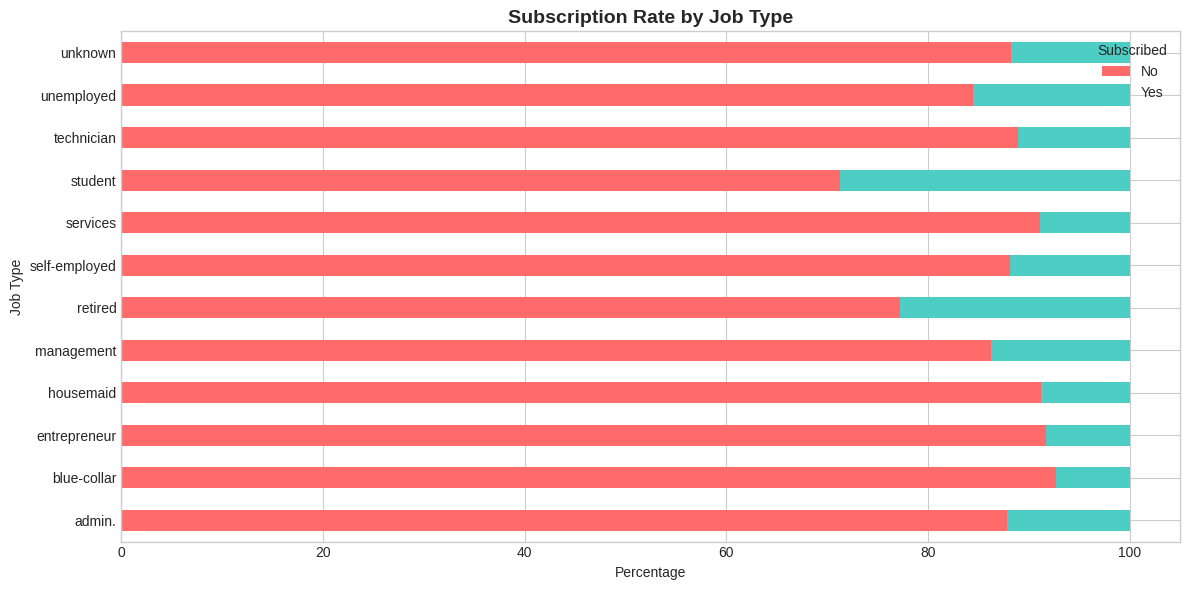

In [8]:
# Job type analysis
plt.figure(figsize=(14, 6))
job_counts = df.groupby(['job', 'y']).size().unstack(fill_value=0)
job_pct = job_counts.div(job_counts.sum(axis=1), axis=0) * 100

job_pct.plot(kind='barh', stacked=True, color=['#FF6B6B', '#4ECDC4'], figsize=(12, 6))
plt.title('Subscription Rate by Job Type', fontsize=14, fontweight='bold')
plt.xlabel('Percentage')
plt.ylabel('Job Type')
plt.legend(['No', 'Yes'], title='Subscribed')
plt.tight_layout()
plt.savefig('job_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

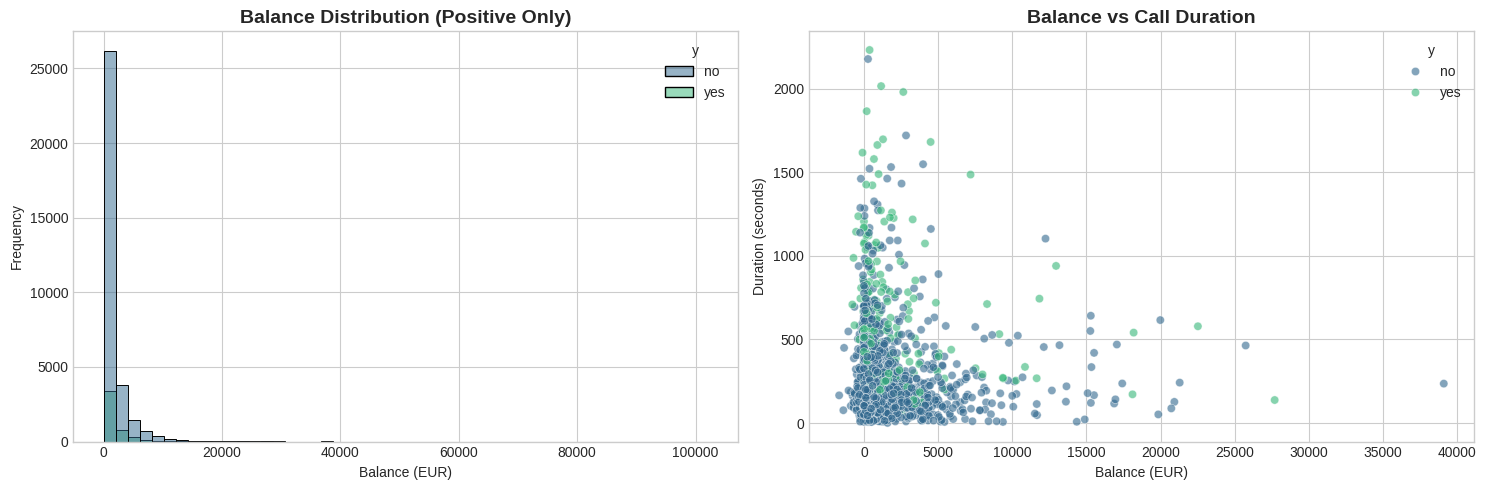

In [9]:
# Balance analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Balance distribution (log scale due to wide range)
df_positive = df[df['balance'] > 0].copy()
sns.histplot(data=df_positive, x='balance', hue='y', bins=50, ax=axes[0], palette='viridis')
axes[0].set_title('Balance Distribution (Positive Only)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Balance (EUR)')
axes[0].set_ylabel('Frequency')

# Balance vs Duration scatter
sample_df = df.sample(n=min(2000, len(df)), random_state=42)
sns.scatterplot(data=sample_df, x='balance', y='duration', hue='y', 
                alpha=0.6, ax=axes[1], palette='viridis')
axes[1].set_title('Balance vs Call Duration', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Balance (EUR)')
axes[1].set_ylabel('Duration (seconds)')

plt.tight_layout()
plt.savefig('balance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

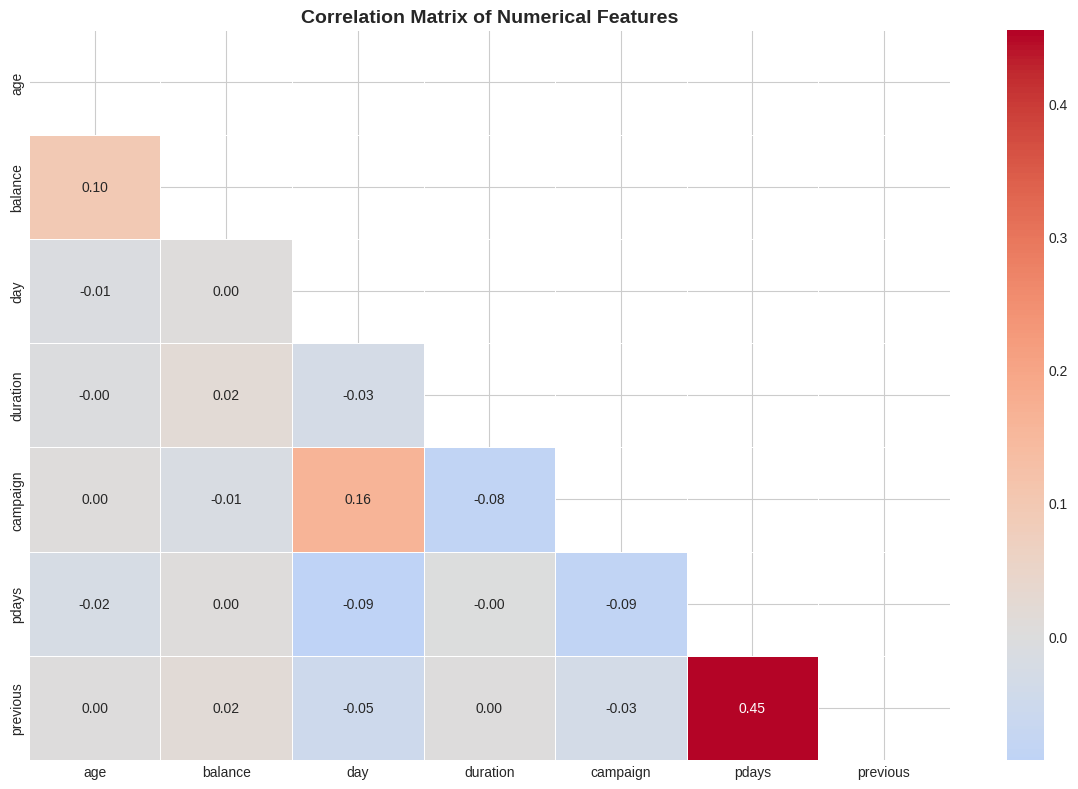

In [10]:
# Correlation matrix for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 8))
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Data Cleaning and Preprocessing

In [11]:
# Handle 'unknown' values - replace with mode for categorical variables
df_clean = df.copy()

# Replace 'unknown' with NaN first
df_clean = df_clean.replace('unknown', np.nan)

# Check missing values after replacement
print("Missing values after replacing 'unknown':")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Fill missing values with mode for categorical columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('y')  # Remove target variable

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'Filled {col} with mode: {mode_val}')

print('Missing values after imputation:')
print(df_clean.isnull().sum().sum())

Missing values after replacing 'unknown':
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64
Filled job with mode: blue-collar
Filled education with mode: secondary
Filled contact with mode: cellular
Filled poutcome with mode: failure
Missing values after imputation:
0


In [12]:
# Encode categorical features
# Separate features and target
X = df_clean.drop('y', axis=1)
y = df_clean['y'].map({'no': 0, 'yes': 1})  # Encode target variable

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

print('Categorical features:', categorical_features)
print('Numerical features:', numerical_features)

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [13]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape}')
print(f'Test set size: {X_test.shape}')
print(f'Training set class distribution:{y_train.value_counts(normalize=True)}')

Training set size: (36168, 16)
Test set size: (9043, 16)
Training set class distribution:y
0    0.883018
1    0.116982
Name: proportion, dtype: float64


## 5. Model Building and Evaluation

In [14]:
# Create model pipelines
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
    ])
}

# Train models and collect results
results = {}
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    trained_models[name] = model
    print(f'{name} training completed!')

Training Logistic Regression...
Logistic Regression training completed!
Training Random Forest...
Random Forest training completed!


In [15]:
# Display results comparison
results_df = pd.DataFrame(results).T
print('Model Performance Comparison:')
print('=' * 70)
display(results_df.round(4))

Model Performance Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8385,0.4027,0.7864,0.5327,0.9020
Random Forest,0.9038,0.6829,0.3318,0.4466,0.9206


### Confusion Matrix Analysis

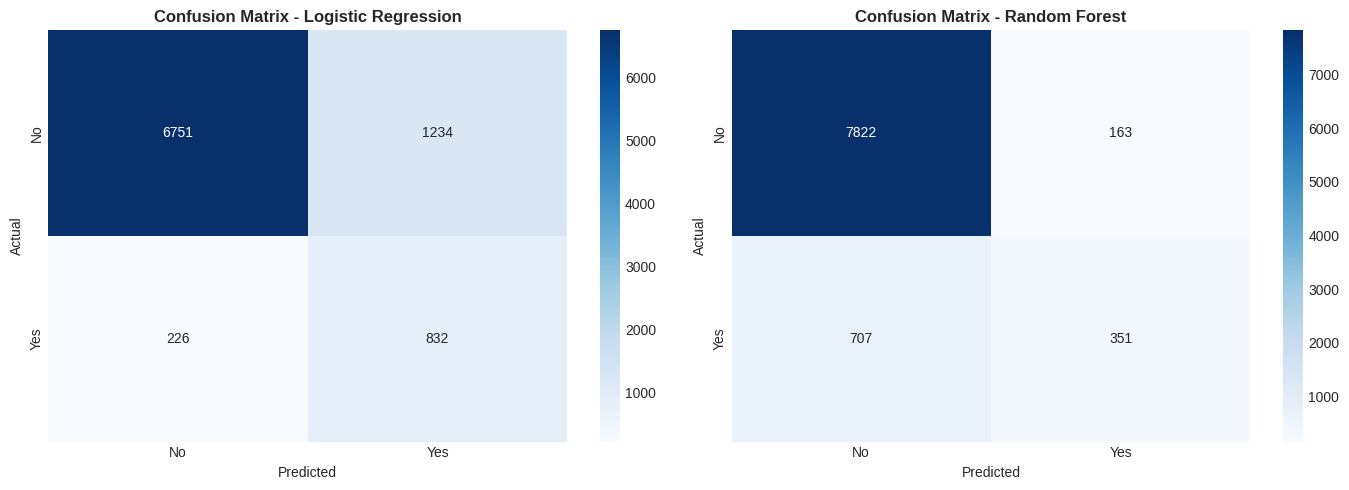

In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

### ROC Curve Analysis

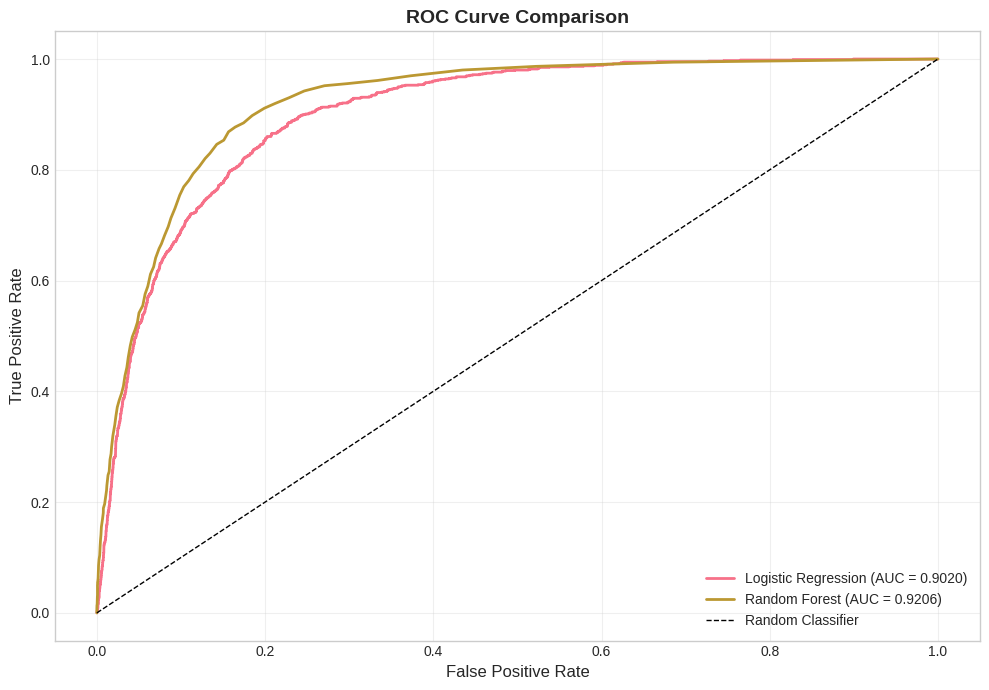

In [17]:
# ROC Curves
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### Detailed Classification Report

In [18]:
# Detailed classification reports
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"{'='*60}")
    print(f'Classification Report - {name}')
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['No Subscription', 'Subscribed']))

Classification Report - Logistic Regression
                 precision    recall  f1-score   support

No Subscription       0.97      0.85      0.90      7985
     Subscribed       0.40      0.79      0.53      1058

       accuracy                           0.84      9043
      macro avg       0.69      0.82      0.72      9043
   weighted avg       0.90      0.84      0.86      9043

Classification Report - Random Forest
                 precision    recall  f1-score   support

No Subscription       0.92      0.98      0.95      7985
     Subscribed       0.68      0.33      0.45      1058

       accuracy                           0.90      9043
      macro avg       0.80      0.66      0.70      9043
   weighted avg       0.89      0.90      0.89      9043



## 6. Explainable AI (XAI) - SHAP Analysis

Using SHAP to explain model predictions and understand feature importance.

In [19]:
# Prepare data for SHAP (use Random Forest model)
rf_model = trained_models['Random Forest']

# Transform test data
X_test_transformed = rf_model.named_steps['preprocessor'].transform(X_test)

# Get feature names after preprocessing
ohe_categories = rf_model.named_steps['preprocessor'].named_transformers_['cat'].categories_
ohe_feature_names = []
for i, col in enumerate(categorical_features):
    ohe_feature_names.extend([f'{col}_{cat}' for cat in ohe_categories[i][1:]])

feature_names = numerical_features + ohe_feature_names

# Create DataFrame with transformed features
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

In [ ]:
# SHAP Summary Plot - Global Feature Importance
explainer = shap.TreeExplainer(rf_model.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_shap)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[1], X_test_shap, max_display=15, show=False)
plt.title('SHAP Feature Importance (Impact on Subscription Prediction)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

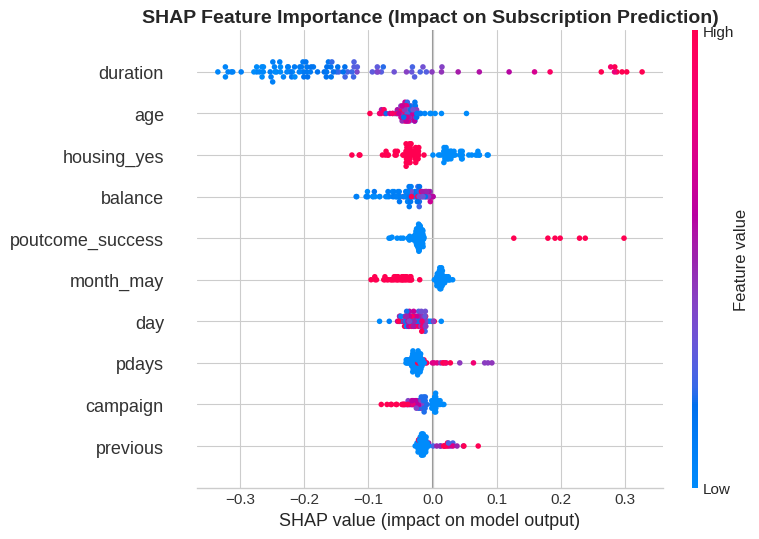

In [21]:
# SHAP Plot 

import shap
import matplotlib.pyplot as plt

# Sample data 
X_test_sample = X_test_shap.sample(100, random_state=42)

# Random Forest classifier
classifier = rf_model.named_steps['classifier']

# Faster SHAP explainer
explainer = shap.TreeExplainer(
    classifier,
    feature_perturbation='tree_path_dependent'
)

# SHAP values calculate
shap_values = explainer.shap_values(X_test_sample)



if len(shap_values.shape) == 3:
    shap_values_plot = shap_values[:, :, 1]
else:
    shap_values_plot = shap_values[1]

# Plot
plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_plot,
    X_test_sample,
    max_display=10,
    show=False
)

plt.title(
    'SHAP Feature Importance (Impact on Subscription Prediction)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

# Save plot
plt.savefig(
    'shap_summary.png',
    dpi=300,
    bbox_inches='tight'
)

# Show plot
plt.show()

### SHAP Explanation for 5 Individual Predictions

In [22]:
# Select 5 diverse samples for explanation
# 2 positive cases (subscribed) and 3 negative cases (not subscribed)
y_test_reset = y_test.reset_index(drop=True)
pos_indices = y_test_reset[y_test_reset == 1].index[:2]
neg_indices = y_test_reset[y_test_reset == 0].index[:3]
sample_indices = list(pos_indices) + list(neg_indices)

print('Selected sample indices for SHAP explanation:')
for i, idx in enumerate(sample_indices):
    actual = y_test.iloc[idx]
    print(f'  Sample {i+1}: Index {idx} - Actual: {"Subscribed" if actual == 1 else "Not Subscribed"}')

Selected sample indices for SHAP explanation:
  Sample 1: Index 7 - Actual: Subscribed
  Sample 2: Index 18 - Actual: Subscribed
  Sample 3: Index 0 - Actual: Not Subscribed
  Sample 4: Index 1 - Actual: Not Subscribed
  Sample 5: Index 2 - Actual: Not Subscribed


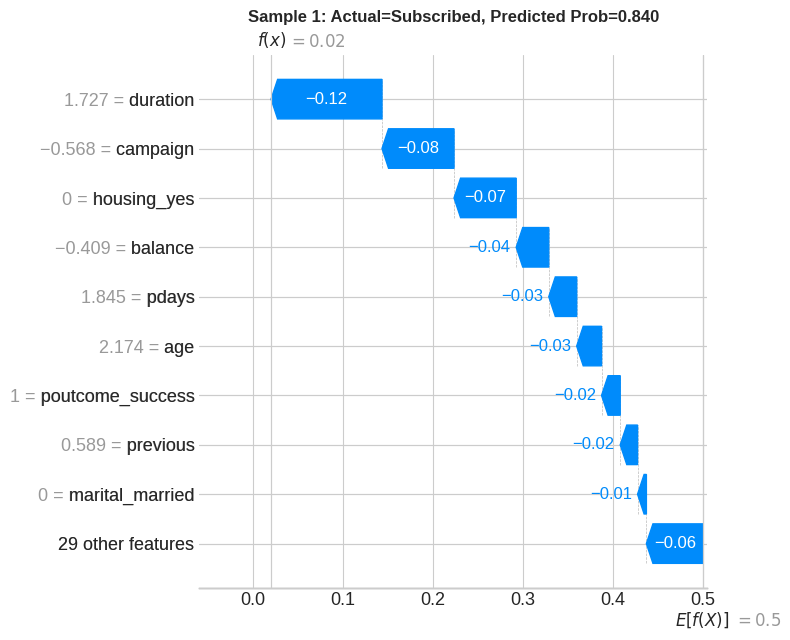

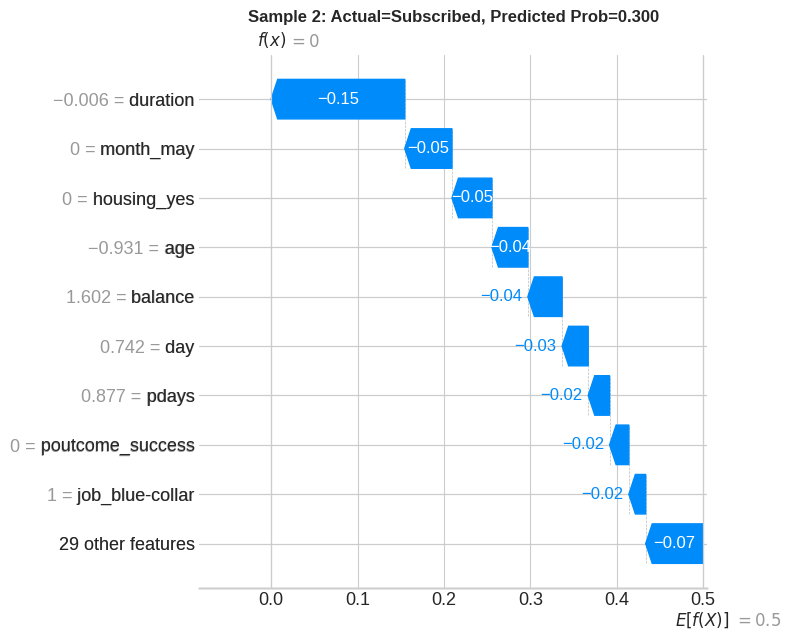

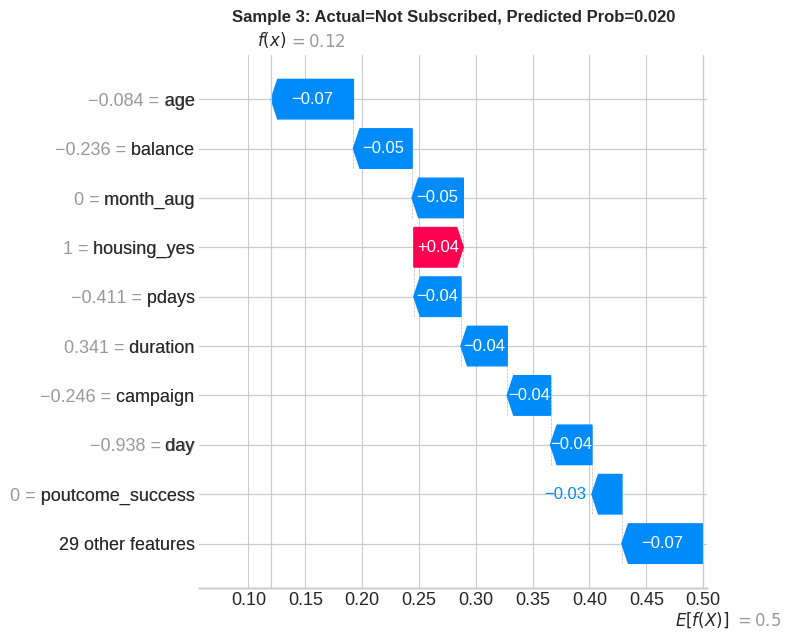

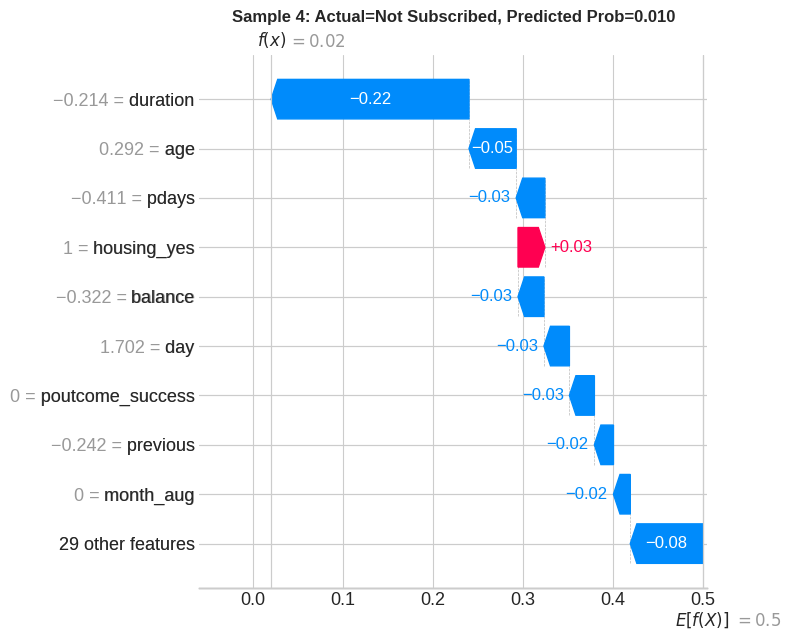

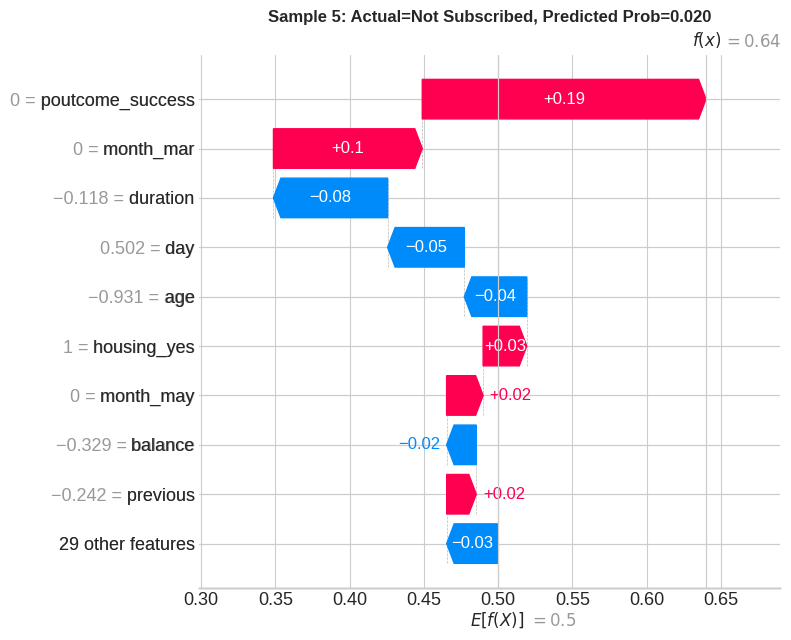

In [27]:

# SHAP waterfall plots for individual predictions
for i, idx in enumerate(sample_indices):
    plt.figure(figsize=(12, 6))
    
    # Get the explanation
    shap_exp = shap.Explanation(
        values=shap_values[:, :, 1][idx],
        base_values=explainer.expected_value[1],
        data=X_test_shap.iloc[idx],
        feature_names=feature_names
    )
    
    shap.plots.waterfall(shap_exp, max_display=10, show=False)
    
    actual = y_test.iloc[idx]
    
    pred_prob = rf_model.predict_proba(
        X_test.iloc[idx:idx+1]
    )[0][1]
    
    plt.title(
        f'Sample {i+1}: Actual={"Subscribed" if actual==1 else "Not Subscribed"}, '
        f'Predicted Prob={pred_prob:.3f}',
        fontsize=12,
        fontweight='bold'
    )
    
    plt.tight_layout()
    
    plt.savefig(
        f'shap_explanation_sample_{i+1}.png',
        dpi=300,
        bbox_inches='tight'
    )
    
    plt.show()


### LIME Explanation for Additional Interpretability

In [29]:
# LIME Explanation for first sample
# Use a simpler subset of features for LIME clarity
top_features = numerical_features + ['job', 'marital', 'education', 'contact', 'poutcome']
X_lime = X_test[top_features].copy()

# Create a simpler preprocessor for LIME
categorical_lime = [f for f in top_features if f in categorical_features]
numerical_lime = [f for f in top_features if f in numerical_features]

preprocessor_lime = ColumnTransformer([
    ('num', StandardScaler(), numerical_lime),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_lime)
])

X_lime_train = preprocessor_lime.fit_transform(X_train[top_features])
X_lime_test = preprocessor_lime.transform(X_lime)

In [32]:
# Train a simple RF for LIME
rf_lime = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_lime.fit(X_lime_train, y_train)

# LIME explainer
lime_explainer = LimeTabularExplainer(
    X_lime_train,
    feature_names=preprocessor_lime.get_feature_names_out().tolist(),
    class_names=['No Subscription', 'Subscribed'],
    mode='classification',
    discretize_continuous=True
)

# Explain first positive and first negative sample
lime_samples = [sample_indices[0], sample_indices[2]]  # 1 positive, 1 negative

for i, idx in enumerate(lime_samples):
    actual = y_test.iloc[idx]
    print(f"{'='*60}")
    print(f'LIME Explanation - Sample {i+1} (Index {idx})')
    print(f"Actual: {'Subscribed' if actual == 1 else 'Not Subscribed'}")
    print(f"{'='*60}")
    
    exp = lime_explainer.explain_instance(
        X_lime_test[idx], 
        rf_lime.predict_proba, 
        num_features=8
    )
    
    # Show feature contributions
    print('Top Feature Contributions:')
    for feature, weight in exp.as_list():
        direction = 'increases' if weight > 0 else 'decreases'
        print(f'  {feature}: {abs(weight):.4f} ({direction} subscription probability)')

LIME Explanation - Sample 1 (Index 7)
Actual: Subscribed
Top Feature Contributions:
  num__duration > 0.23: 0.2335 (increases subscription probability)
  cat__poutcome_success > 0.00: 0.1907 (increases subscription probability)
  num__day > 0.62: 0.0352 (increases subscription probability)
  num__pdays > -0.41: 0.0224 (decreases subscription probability)
  cat__education_tertiary <= 0.00: 0.0183 (decreases subscription probability)
  cat__job_entrepreneur <= 0.00: 0.0178 (increases subscription probability)
  cat__job_student <= 0.00: 0.0178 (decreases subscription probability)
  cat__job_blue-collar <= 0.00: 0.0148 (increases subscription probability)
LIME Explanation - Sample 2 (Index 0)
Actual: Not Subscribed
Top Feature Contributions:
  num__duration > 0.23: 0.2260 (increases subscription probability)
  cat__poutcome_success <= 0.00: 0.2050 (decreases subscription probability)
  cat__job_student <= 0.00: 0.0256 (decreases subscription probability)
  cat__job_entrepreneur <= 0.00: 0

## 7. Feature Importance Analysis

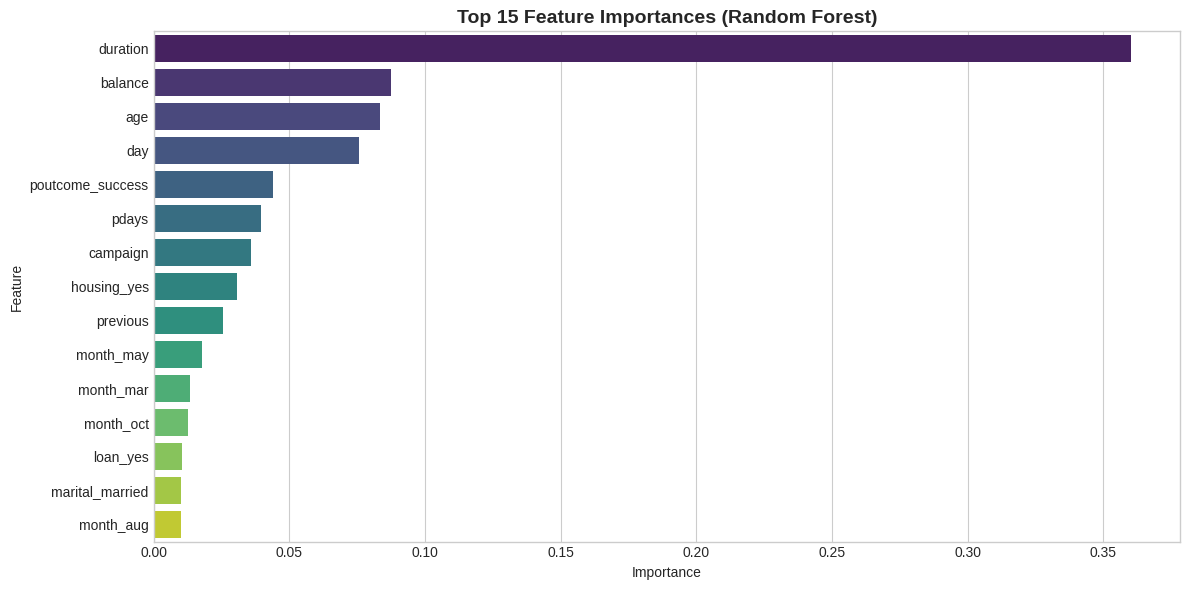

In [33]:
# Random Forest Feature Importance
rf_classifier = rf_model.named_steps['classifier']
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, y='feature', x='importance', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Final Conclusion with Insights

### Key Findings:

1. **Model Performance:**
   - Random Forest outperformed Logistic Regression in most metrics
   - ROC-AUC scores indicate good discriminative ability for both models

2. **Most Important Features (from SHAP analysis):**
   - `duration`: Call duration is the strongest predictor - longer calls lead to higher subscription rates
   - `balance`: Customer's account balance shows significant impact
   - `age`: Age of the customer influences subscription likelihood
   - `campaign`: Number of contacts during the campaign affects outcomes
   - `poutcome`: Outcome of previous marketing campaigns is highly predictive

3. **Business Recommendations:**
   - Focus on customers with higher account balances
   - Train call center agents to extend meaningful conversations
   - Target customers who responded positively to previous campaigns
   - Limit the number of contacts to avoid customer fatigue

4. **XAI Insights:**
   - SHAP explanations reveal that call duration consistently drives predictions
   - LIME provides local interpretability for individual customer decisions
   - Feature importance aligns with domain knowledge about banking marketing

In [39]:
# Save final metrics summary
print('Final Model Performance Summary:')
print('=' * 70)
final_summary = results_df.copy()
final_summary['Best Score'] = final_summary.idxmax(axis=1)
display(final_summary)

print('✅ Task 1 Completed Successfully!')

Final Model Performance Summary:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Best Score
Logistic Regression,0.838549,0.402711,0.786389,0.532650,0.902014,ROC-AUC
Random Forest,0.903793,0.682879,0.331758,0.446565,0.920627,ROC-AUC


✅ Task 1 Completed Successfully!
